# **Seasonal Agriculture Performance Analysis**

## **Major Data Analytics Project**

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### **Project Goal**
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

### **Problem Statement**
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

### **Project Objectives**
* Understand the structure and quality of the agricultural dataset.
* Clean and prepare the data for analysis.
* Explore seasonal patterns in the dataset.
* Perform descriptive and statistical analysis.
* Investigate relationships among relevant variables.
* Compare agricultural performance across seasons and other meaningful groups.
* Use appropriate univariate, bivariate and multivariate visualizations.
Identify significant findings from the data.
* Develop evidence-based insights and recommendations.

In [329]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [330]:
# Ensuring Visualizations are Shown in the Notebook
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### **Dataset**
The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** seasonal_agriculture_performance_dataset.csv

In [331]:
# Load the Datset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

### **Initial Data Understanding**
In this section, we take a first look at the dataset to understand its structure, such as, how many records and columns it has, what the data looks like, what columns are present and what data types they hold.

In [332]:
# Number of Rows and Columns
print("The number of rows and columns respectively is", df.shape)

The number of rows and columns respectively is (4000, 28)


In [333]:
# First 5 Rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [334]:
# Last 5 Rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [335]:
# 3 Random Samples of Records
df.sample(3, random_state = 42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70


In [336]:
# Column Names
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [337]:
# Data Type of Columns and Their Count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [338]:
# Numerical Statistical Summary
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [339]:
# Categorial Summary
df.describe(include = "object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


### **Data Quality Analysis**

In [340]:
# Missing Values in Descending Order
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


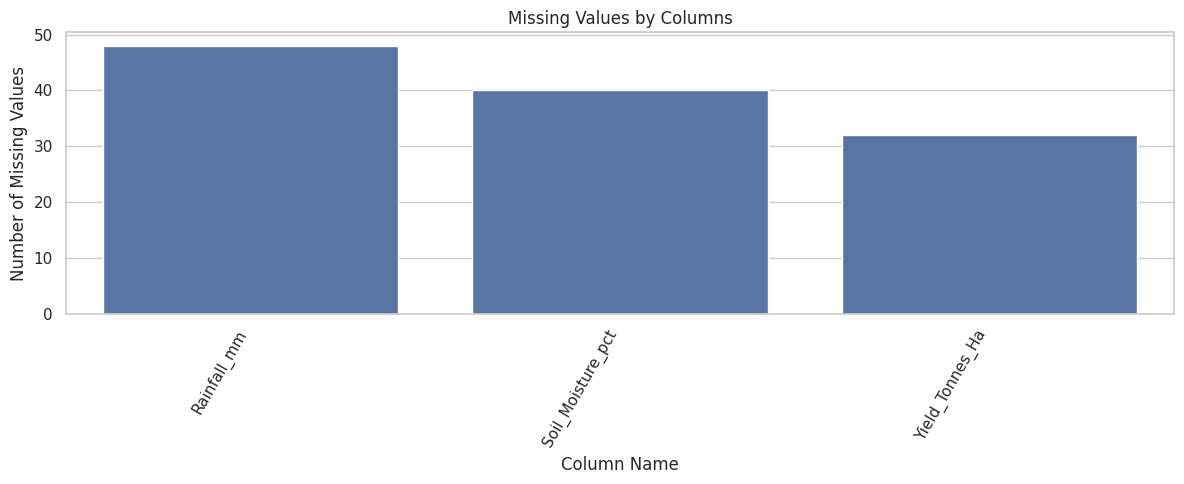

In [341]:
# Visualization of Missing Values
plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]

if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column Name")
    plt.title("Missing Values by Columns")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [342]:
# Duplicate Records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [343]:
# Removal of Duplicate Records
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [344]:
# Data Types
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [345]:
# Checking Missing Values After Duplicate Removal
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


The dataset has some missing values in numerical columns and a small number of duplicate records. We will fill the missing numerical values with the column median and remove all duplicate rows before continuing the analysis.

In [346]:
# Unique Values in Categorical Data
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


### **Missing Value Treatment**
We found missing values only in numerical columns. To handle them, we replace each missing value with the median of that column.

Other common methods include mean imputation, mode imputation, filling with a fixed value or dropping the rows entirely. The median was chosen here because it is not affected by extreme values (outliers), which are common in agricultural data like yield and profit figures.

In [347]:
# Median in place of Missing Values for Numerical Columns
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### **Feature / Variable Review**
Before analysis, it helps to know what kind of columns we are working with. Here we separate the dataset into numerical columns (columns with measurable numbers like yield, rainfall and profit) and categorical columns (columns with labels or groups like crop name, season and irrigation method). This helps us choose the right analysis techniques for each type.

In [348]:
# Numerical and Categorical Columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


### **Statistical Analysis**
Statistical analysis helps us summarise the dataset using numbers. Instead of looking at all 4000 rows, we use measures like mean, median and standard deviation to understand the overall picture quickly.

In [349]:
# Descriptive Statistics
stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


The range tells us how spread out a column's values are from lowest to highest. The IQR (Interquartile Range) tells us the spread of the middle 50% of values, i.e., a large IQR means the data is quite varied, a small one means most values are clustered closely together.

In [350]:
# Statistical Summary = Mean, Median, Standard Deviation, Minimum and Maximum
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


If the mean and median of a column are close to each other, the data is fairly balanced. If they are far apart, it usually means there are some very high or very low values pulling the mean away which would be something worth investigating further.

In [351]:
# Seasonal Descriptive Summary
season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])

season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

This table breaks down the same statistics by season. It lets us quickly spot whether Kharif, Rabi or Zaid differs meaningfully in yield, profit, rainfall or any other metric.

### **Univariate Analysis**
Univariate analysis looks at one variable at a time. The goal is to understand how each individual column is distributed, where most values sit, how spread out they are and whether there are any unusual patterns. We use histograms to see frequency distribution and box plots to spot outliers.

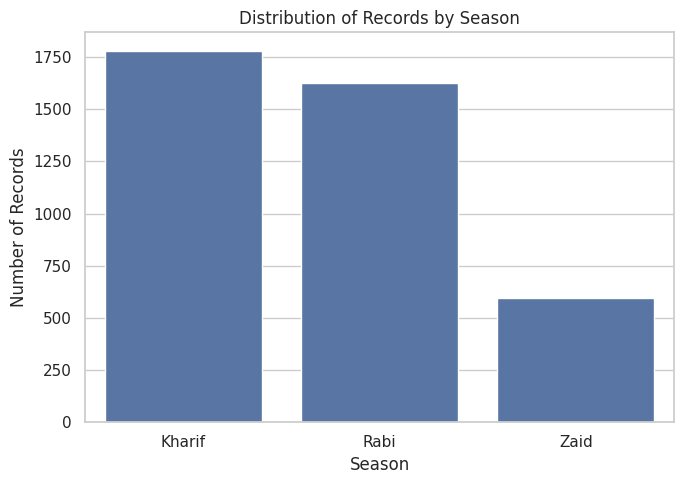

In [352]:
# Season Distribution - Count Plot
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

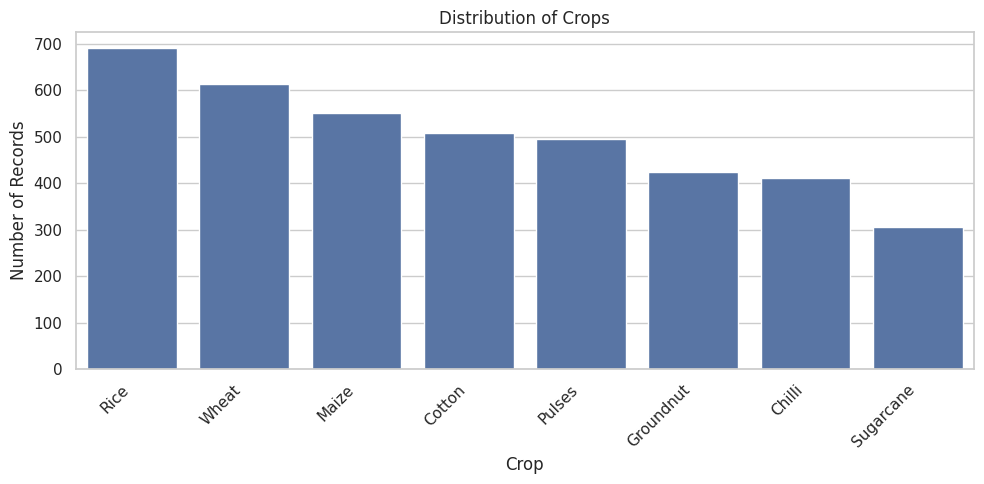

In [353]:
# Crop Distribution - Count Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

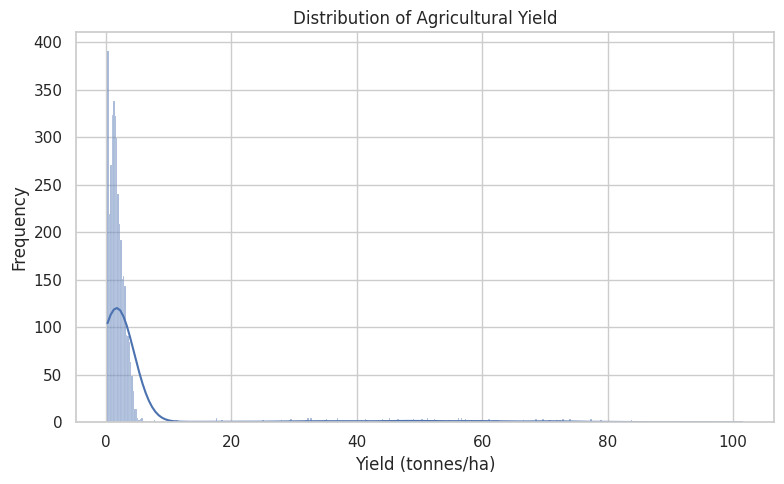

In [354]:
# Yield Distribution - Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

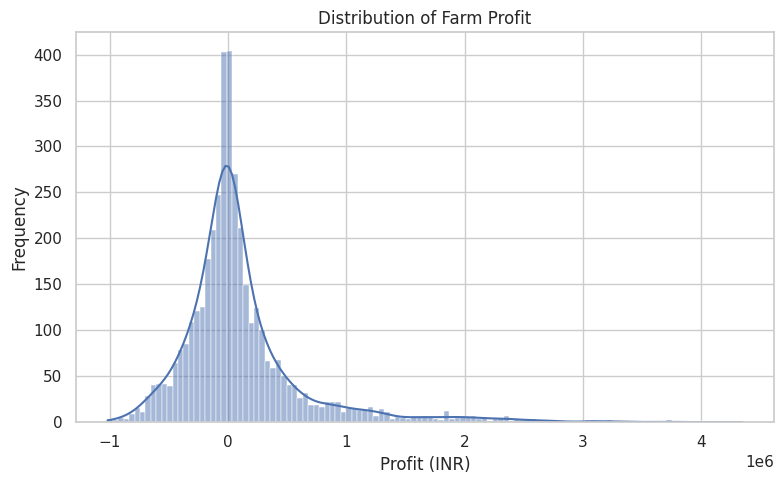

In [355]:
# Profit Distribution - Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

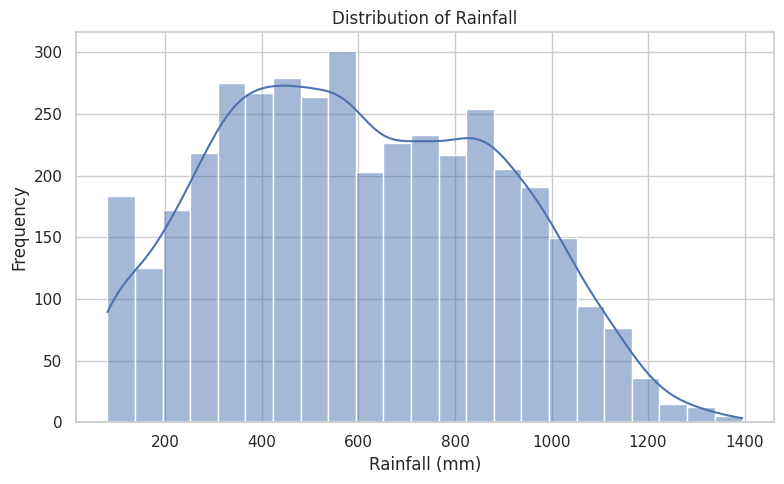

In [356]:
# Rainfall Distribution - Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

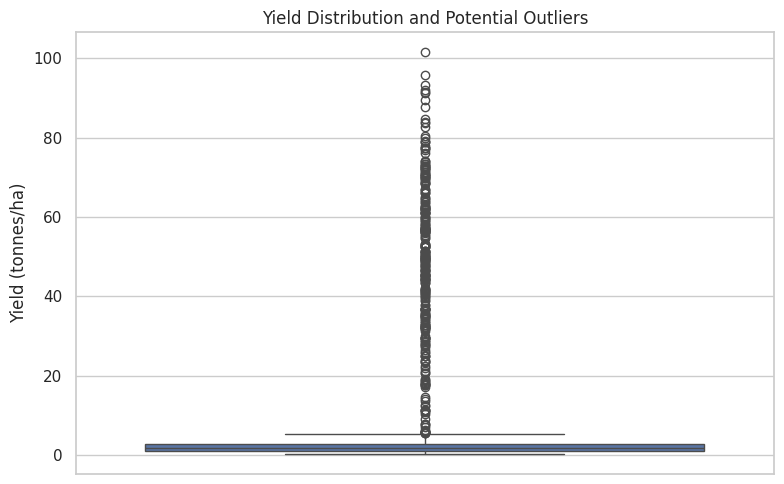

In [357]:
# Yield Distribution - Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

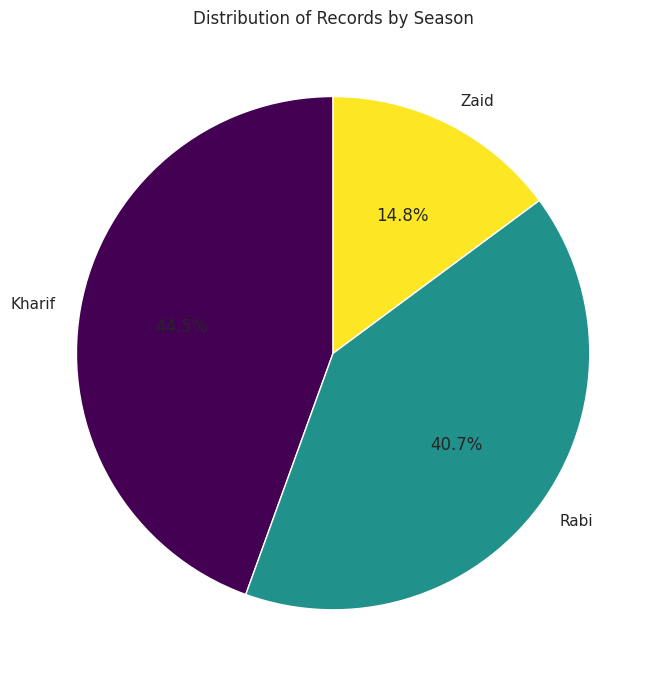

In [358]:
# Season Distribution - Pie Chart
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

### **Outlier Analysis**
Outliers are data points that are unusually high or low compared to the rest of the values. We use the IQR method to detect them implying any value that falls too far above or below the middle range of a column is flagged as an outlier. We identify them here but do not remove them, as extreme values in agricultural data can be genuine and meaningful.

In [359]:
# IQR-Based Outlier Summary for Numerical Columns
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


### **Bivariate Analysis**
Bivariate analysis looks at two variables together to understand how they relate to each other. Here we explore how yield, profit and water usage change across seasons, how rainfall relates to yield and how farm area connects to production. We use box plots to see distributions and bar charts to compare averages.

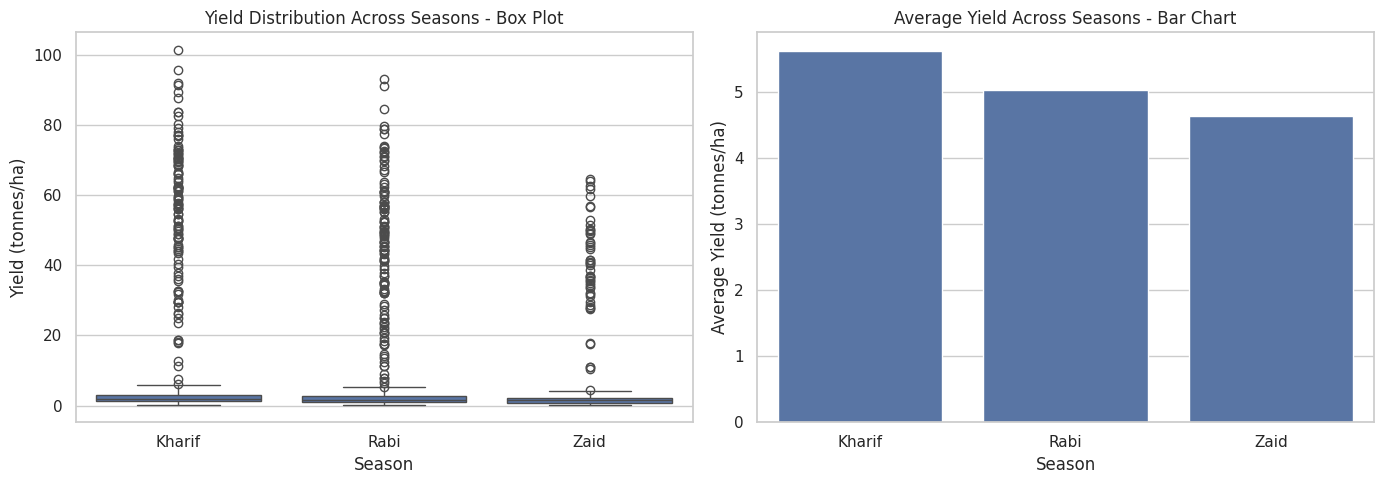

In [360]:
# Season vs Yield - Box Plot and Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", ax=axes[0])
axes[0].set_title("Yield Distribution Across Seasons - Box Plot")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Yield (tonnes/ha)")

sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", errorbar=None, ax=axes[1])
axes[1].set_title("Average Yield Across Seasons - Bar Chart")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Average Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

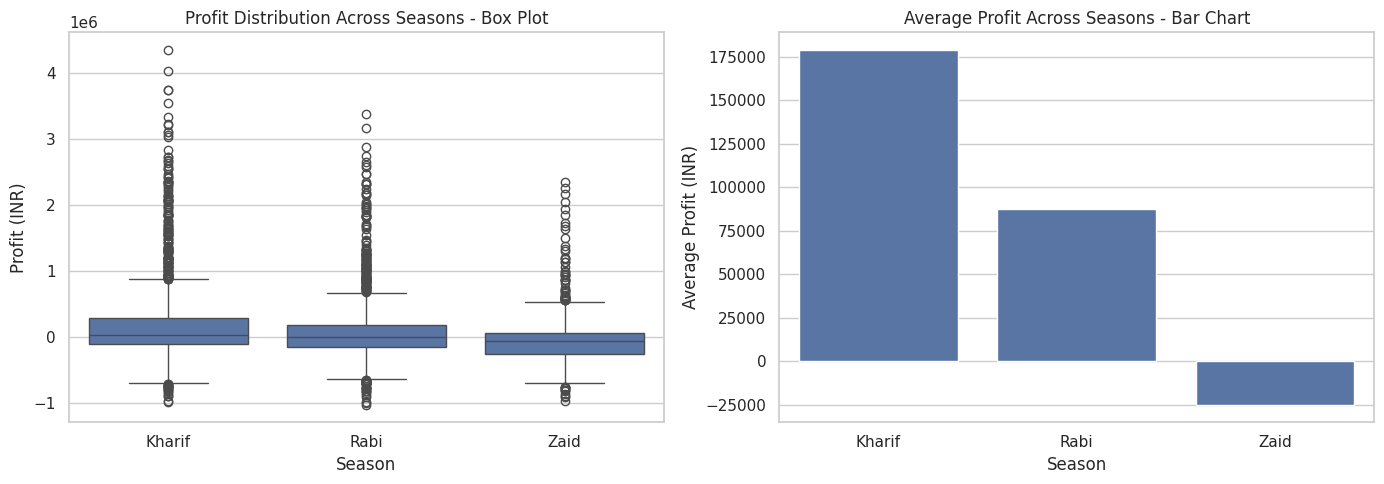

In [361]:
# Season vs Profit - Box Plot and Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Season", y="Profit_INR", ax=axes[0])
axes[0].set_title("Profit Distribution Across Seasons - Box Plot")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Profit (INR)")

sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None, ax=axes[1])
axes[1].set_title("Average Profit Across Seasons - Bar Chart")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Average Profit (INR)")

plt.tight_layout()
plt.show()

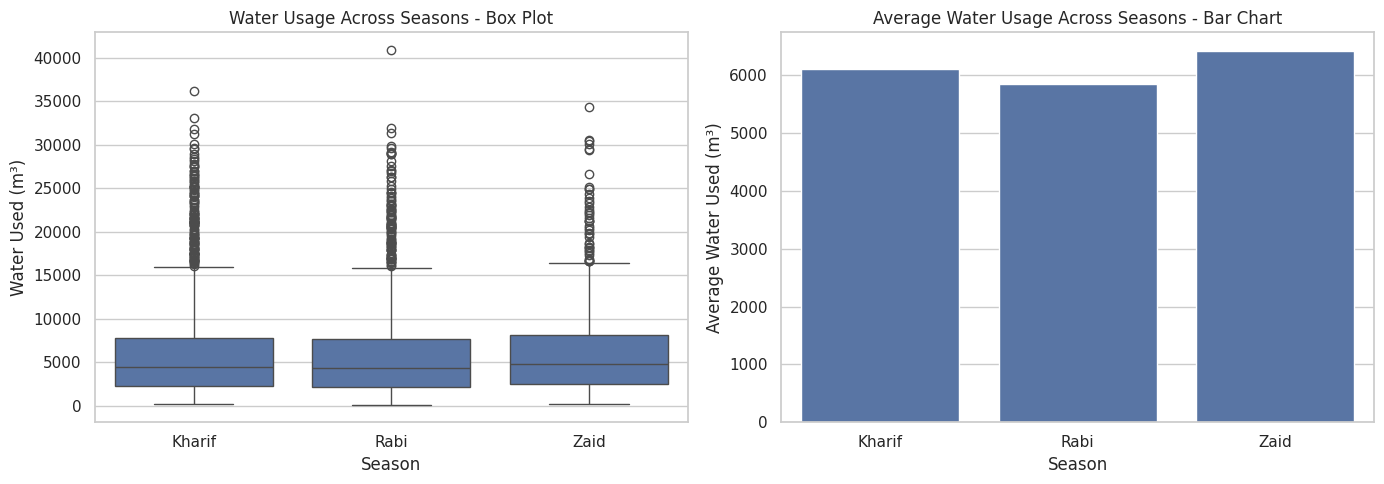

In [362]:
# Season vs Water Usage - Box Plot and Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Season", y="Water_Used_m3", ax=axes[0])
axes[0].set_title("Water Usage Across Seasons - Box Plot")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Water Used (m³)")

sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None, ax=axes[1])
axes[1].set_title("Average Water Usage Across Seasons - Bar Chart")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Average Water Used (m³)")

plt.tight_layout()
plt.show()

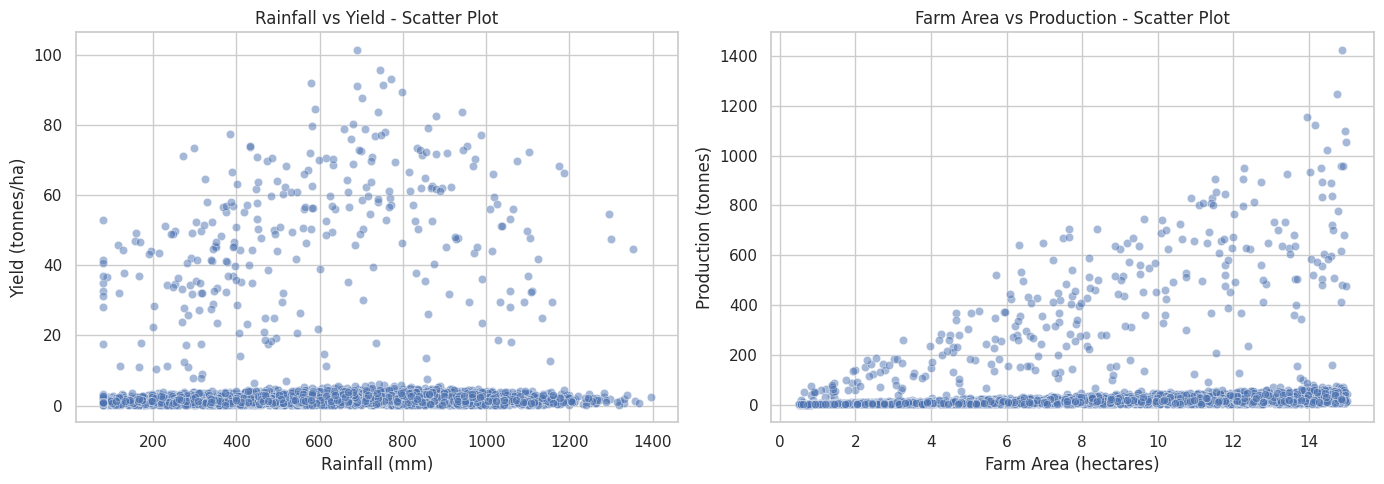

In [363]:
# Rainfall vs Yield and Farm Area vs Production - Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5, ax=axes[0])
axes[0].set_title("Rainfall vs Yield - Scatter Plot")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Yield (tonnes/ha)")

sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5, ax=axes[1])
axes[1].set_title("Farm Area vs Production - Scatter Plot")
axes[1].set_xlabel("Farm Area (hectares)")
axes[1].set_ylabel("Production (tonnes)")

plt.tight_layout()
plt.show()

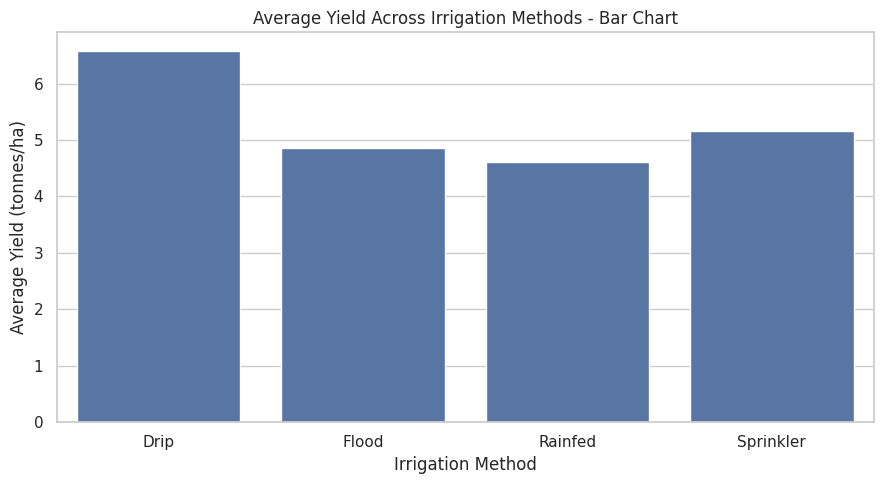

In [364]:
# Irrigation Method vs Yield - Bar Chart
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods - Bar Chart")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### **Multivariate Analysis**
Multivariate analysis looks at three or more variables together at the same time. This helps us spot patterns that only show up when multiple factors are combined; for example, how yield changes across both crop type and season simultaneously.

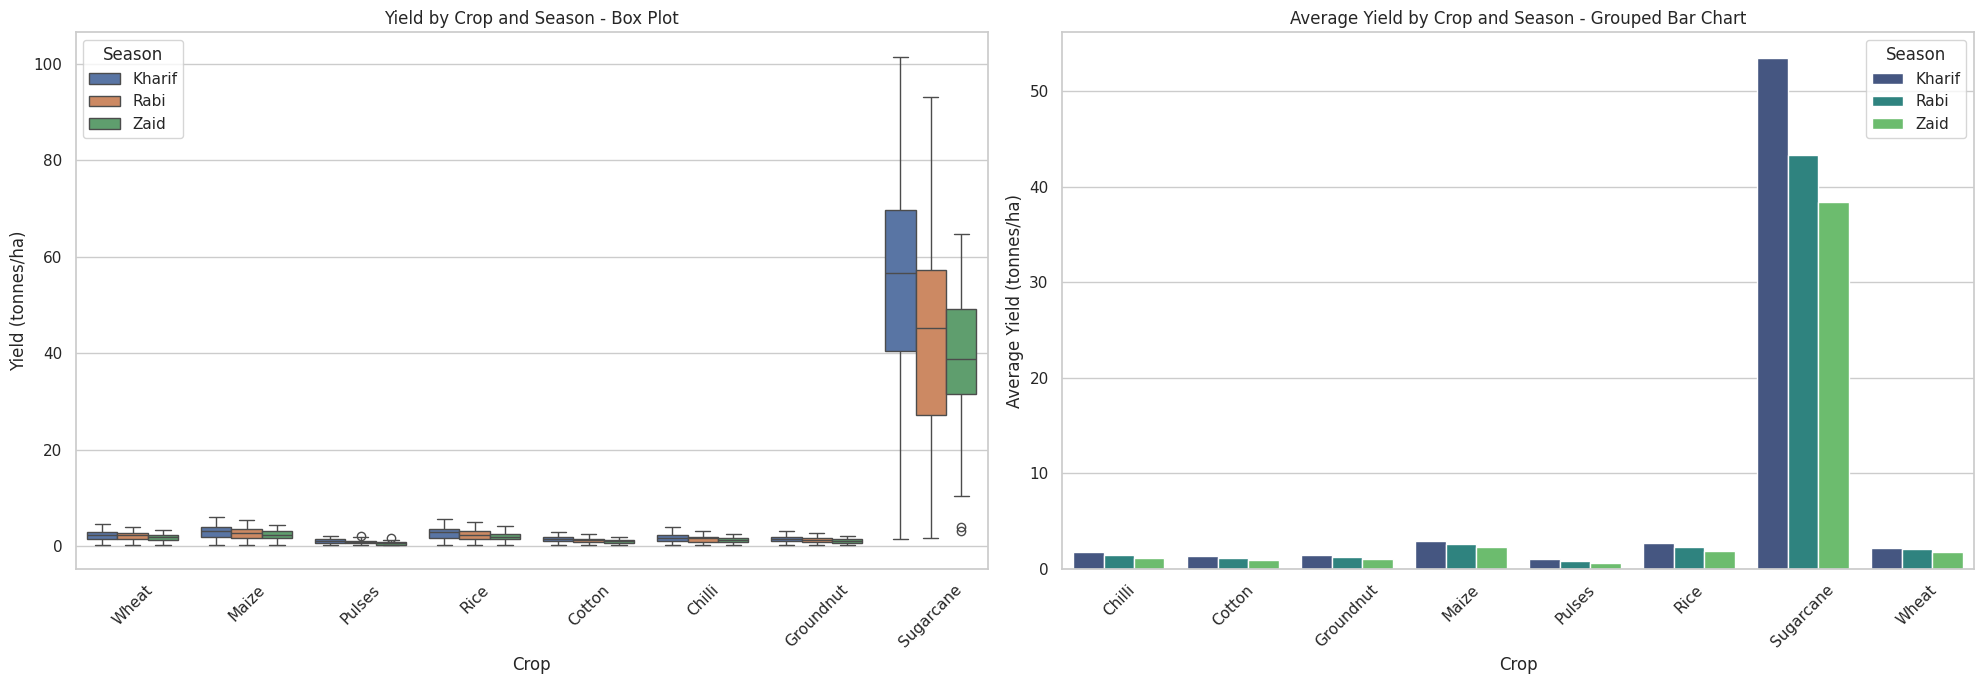

In [365]:
# Season vs Crop vs Yield - Box Plot and Grouped Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season", ax=axes[0])
axes[0].set_title("Yield by Crop and Season - Box Plot")
axes[0].set_xlabel("Crop")
axes[0].set_ylabel("Yield (tonnes/ha)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Season")

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(Average_Yield=("Yield_Tonnes_Ha", "mean"))
      .round(2)
      .reset_index()
)
sns.barplot(data=crop_season_summary, x='Crop', y='Average_Yield', hue='Season', palette='viridis', ax=axes[1])
axes[1].set_title("Average Yield by Crop and Season - Grouped Bar Chart")
axes[1].set_xlabel("Crop")
axes[1].set_ylabel("Average Yield (tonnes/ha)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Season")

plt.tight_layout()
plt.show()

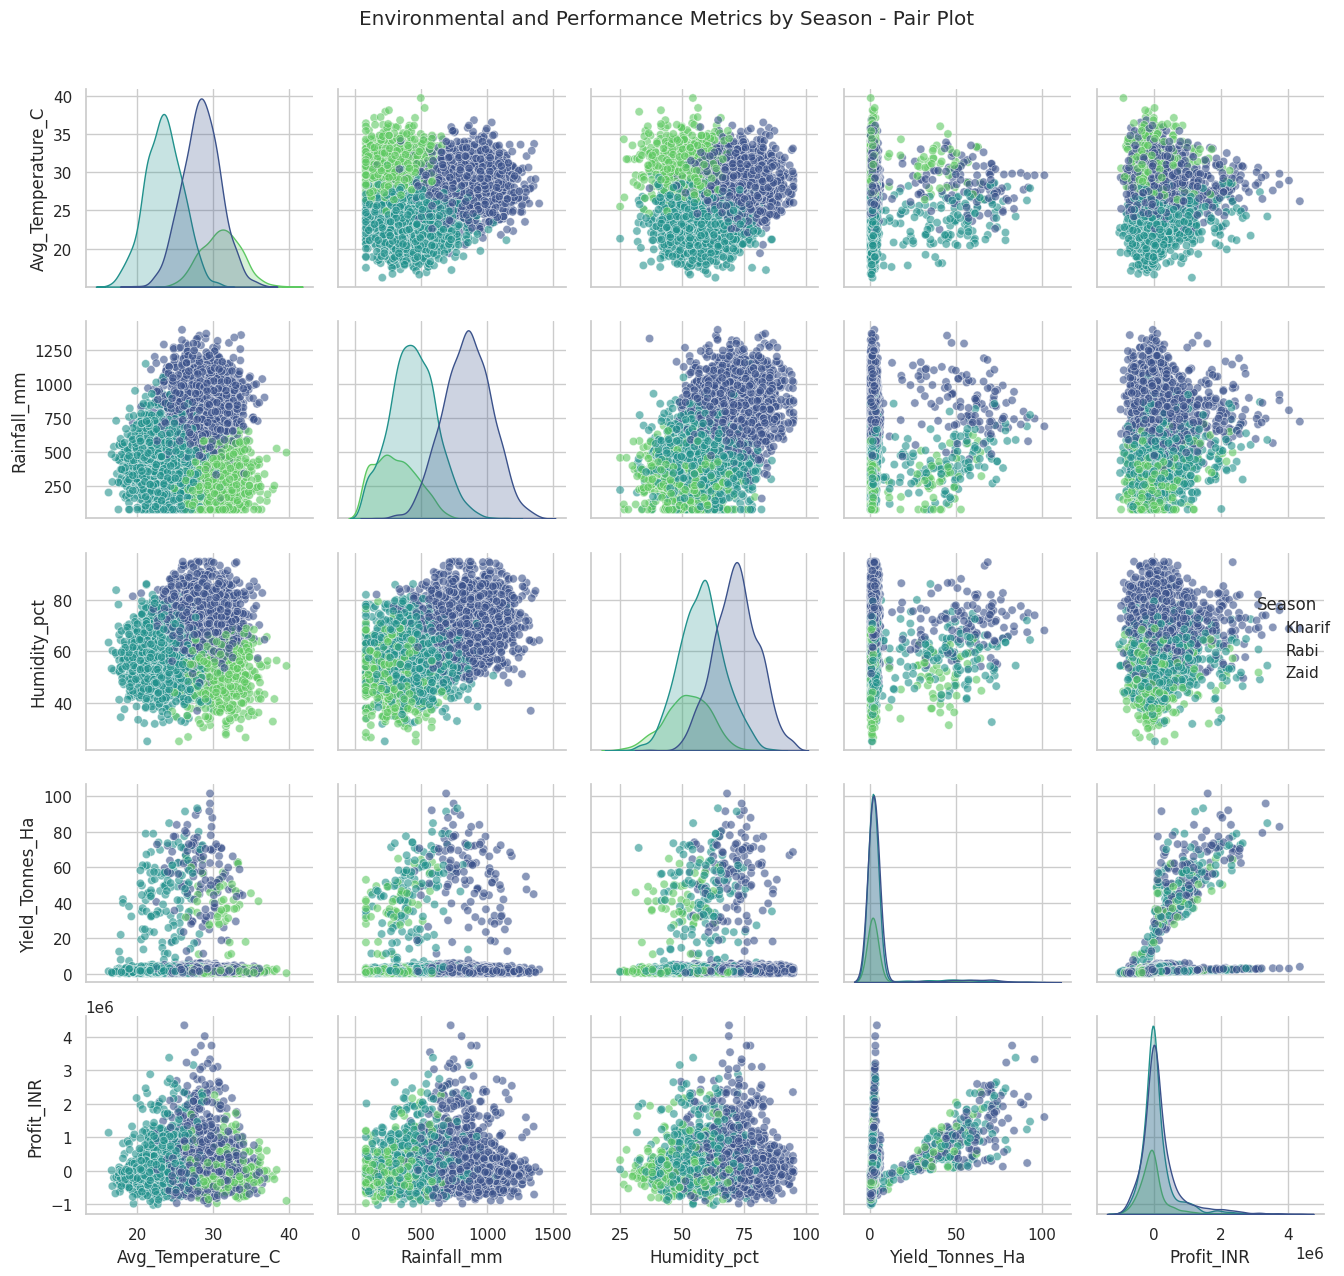

In [366]:
# Environmental and Performance Metrics by Season - Pair Plot
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Environmental and Performance Metrics by Season - Pair Plot', y=1.02)
plt.tight_layout()
plt.show()

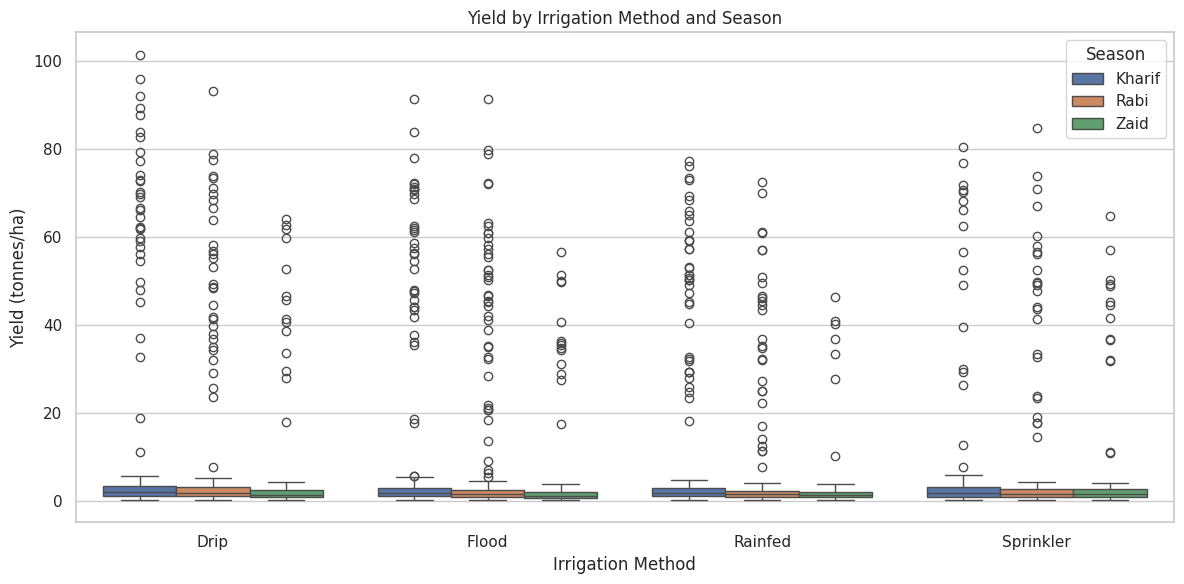

In [367]:
# Yield by Irrigation Method and Season - Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

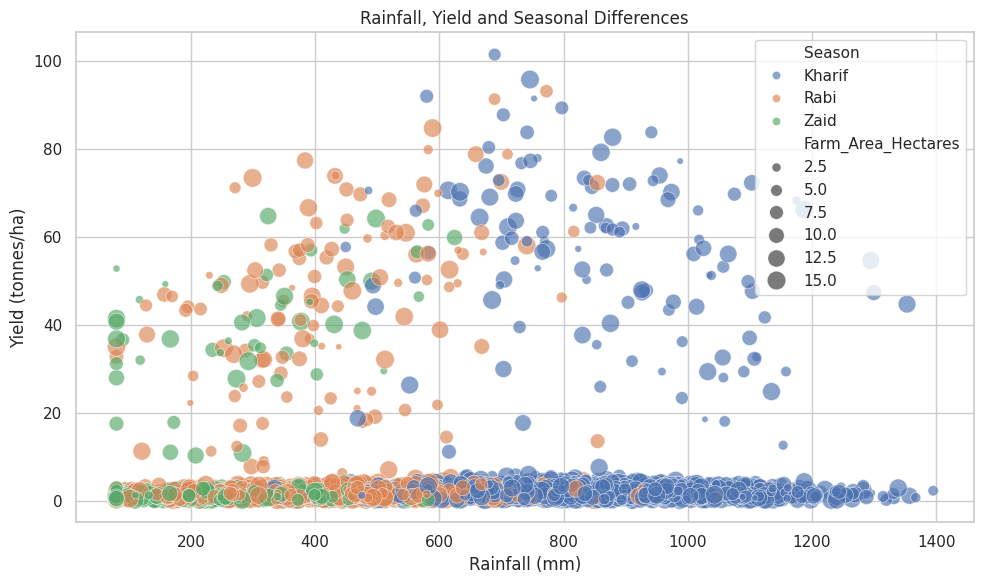

In [368]:
# Rainfall vs Yield by Season and Farm Area - Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

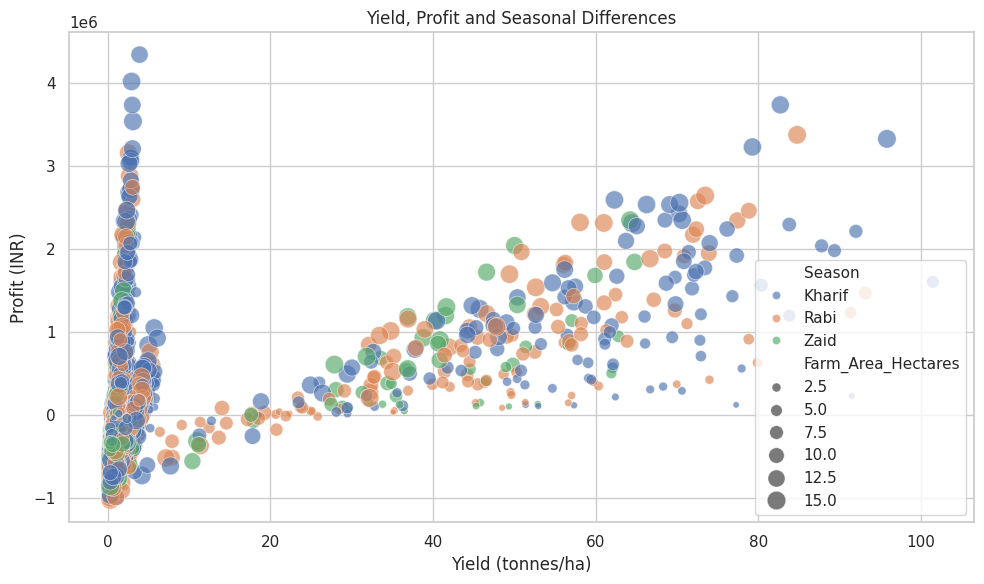

In [369]:
# Profit vs Yield by Season and Farm Area - Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

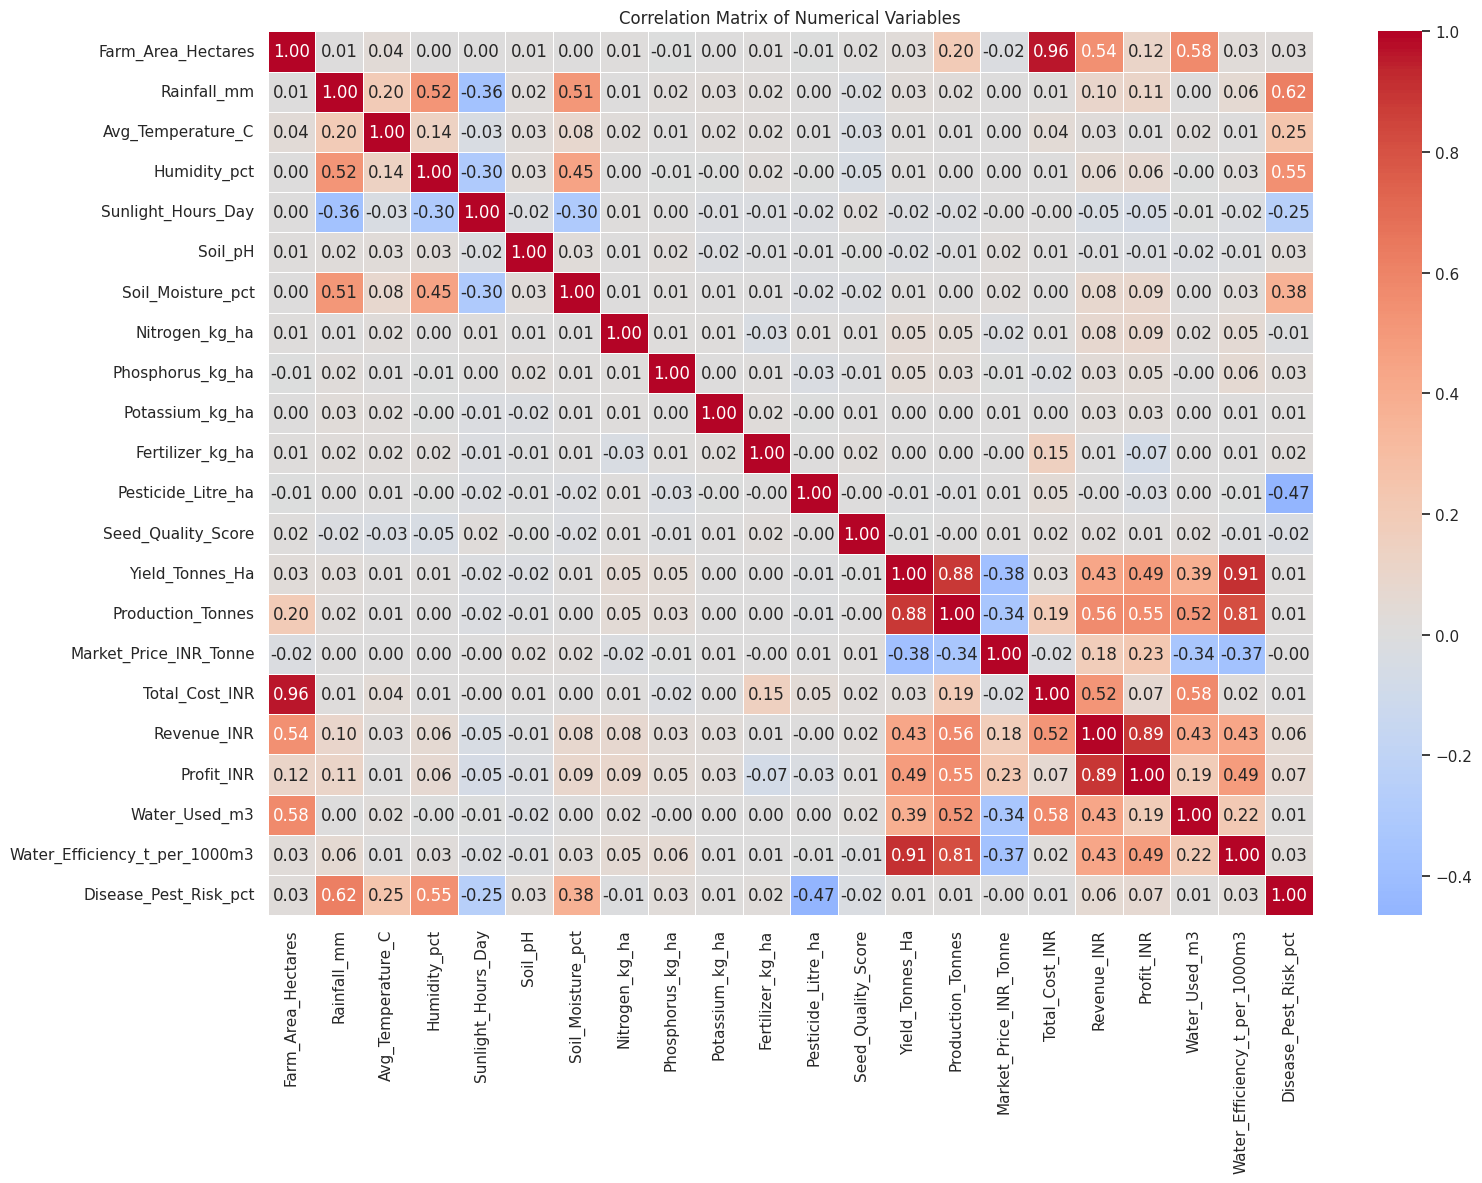

In [370]:
# Correlation Matrix of Numerical Variables - Heatmap
plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### **Seasonal Comparison**
Above we have explored individual variables and their relationships, going forward we are bring it all together by comparing key performance metrics directly across the three seasons. This section summarises yield, profit, production and water usage at the season level and then breaks it down further by crop within each season.

In [371]:
# General Seasonal Summary
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


This table gives us a quick side-by-side comparison of how each season performs overall. Looking at the average yield and average profit columns to helps us see which season performs best and which one struggles.

In [372]:
# Compare Crop Performance Within Each Season
crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

This table ranks crops within each season by their average yield. It helps us identify which crops are the strongest performers in Kharif, Rabi and Zaid individually.

### **Additional Student-Driven Analysis**

### Student Analysis 1: Which crops perform best in each season?

**Question:** Does crop yield and profit change across Kharif, Rabi and Zaid seasons? Which crops do better in which season?

**Why I chose this:** Since this project is about seasonal agricultural performance, I wanted to see which crops actually grow better and earn more profit depending on the season.

In [373]:
# Student Analysis 1: Season-wise Crop Yield and Profit Comparison
crop_season_yield = df.groupby(['Season', 'Crop']).agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2).reset_index()

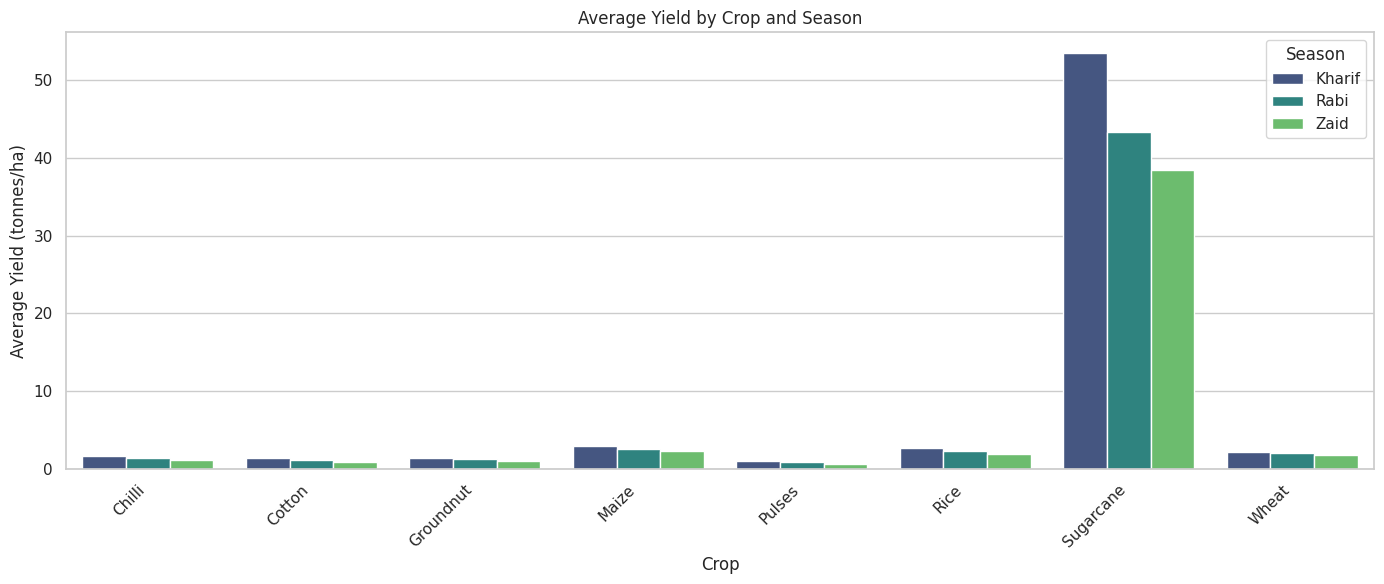

In [374]:
# Visualization 1: Average Yield by Crop and Season
plt.figure(figsize=(14, 6))
sns.barplot(data=crop_season_yield, x='Crop', y='Average_Yield', hue='Season', palette='viridis')
plt.title('Average Yield by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tonnes/ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

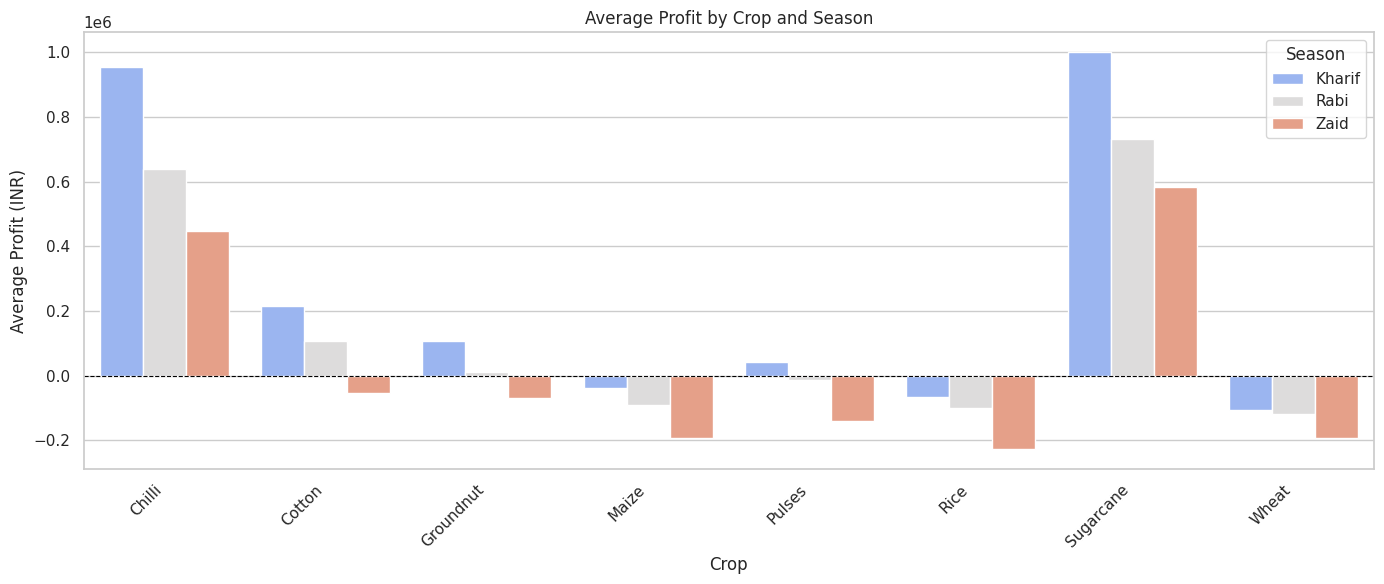

In [375]:
# Visualization 2: Average Profit by Crop and Season
plt.figure(figsize=(14, 6))
sns.barplot(data=crop_season_yield, x='Crop', y='Average_Profit', hue='Season', palette='coolwarm')
plt.title('Average Profit by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

**Interpretation:**

Sugarcane gives the highest yield in all three seasons. In Kharif it gives 53.46 tonnes/ha, in Rabi 43.29 tonnes/ha and in Zaid 38.42 tonnes/ha. Chilli and Sugarcane are the only crops that make profit in all seasons. Crops like Wheat, Rice and Maize actually show negative profit on average, meaning the cost of growing them is higher than what farmers earn. Kharif season overall has the best performance.

**Limitation:** Just because a crop gives high yield does not mean every farmer should grow it. Factors like water availability, soil type and local market prices also matter and are not fully captured here.

### Student Analysis 2: How is NPK used across seasons and does it affect yield?

**Question:** Do farmers apply different amounts of Nitrogen, Phosphorus and Potassium in different seasons? Does using more nutrients mean better yield?

**Why I chose this:** Nitrogen, Phosphorus and Potassium are the three most important nutrients for crop growth. I wanted to check if seasonal farming practices differ in how these nutrients are used and whether that explains the yield differences we see.

In [376]:
# Student Analysis 2: NPK Nutrient Usage by Season and Relationship with Yield
# Summary table
npk_season = df.groupby('Season')[['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Yield_Tonnes_Ha']].mean().round(2)
print("Average NPK and Yield by Season:")
print(npk_season)

Average NPK and Yield by Season:
        Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha  Yield_Tonnes_Ha
Season                                                                    
Kharif          120.02             58.10           105.30             5.63
Rabi            120.40             57.31           103.93             5.04
Zaid            120.53             58.13           105.42             4.64


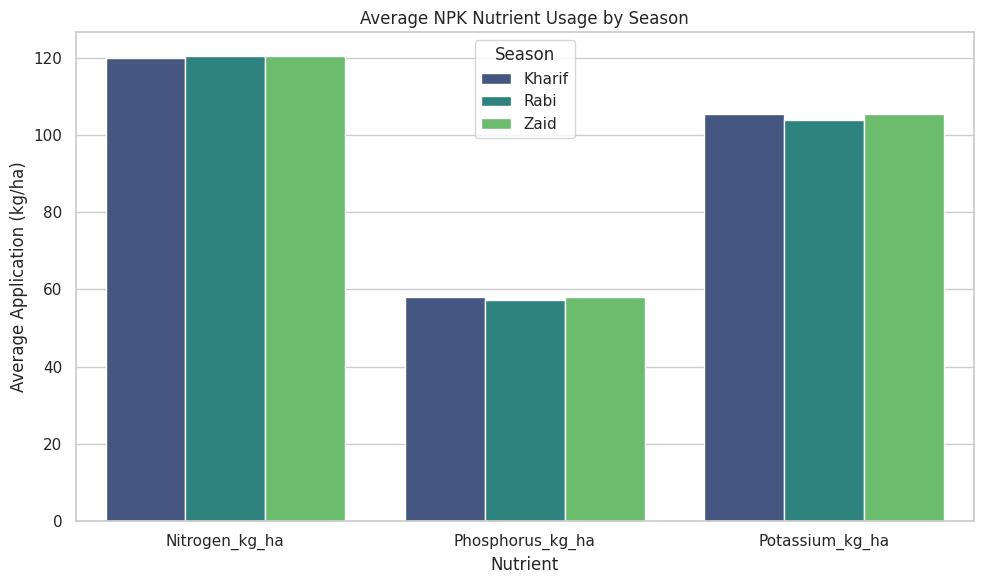

In [377]:
# Visualization 1: NPK by Season - Grouped Bar Chart
npk_melted = df.groupby('Season')[['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']].mean().round(2).reset_index()
npk_melted = npk_melted.melt(id_vars='Season', var_name='Nutrient', value_name='Average_kg_ha')

plt.figure(figsize=(10, 6))
sns.barplot(data=npk_melted, x='Nutrient', y='Average_kg_ha', hue='Season', palette='viridis')
plt.title('Average NPK Nutrient Usage by Season')
plt.xlabel('Nutrient')
plt.ylabel('Average Application (kg/ha)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

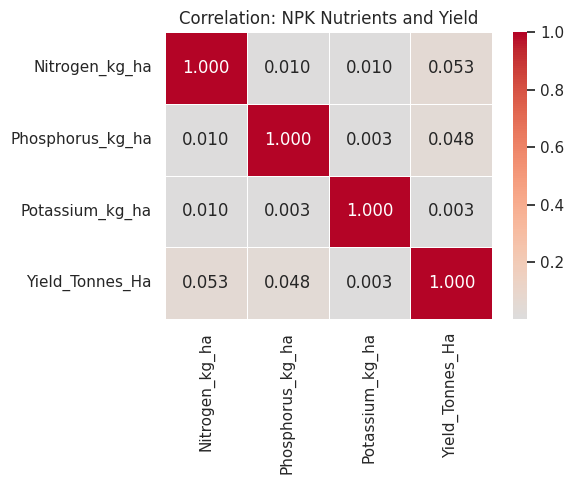

In [378]:
# Visualization 2: Correlation of NPK with Yield
npk_corr = df[['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Yield_Tonnes_Ha']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(npk_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation: NPK Nutrients and Yield')
plt.tight_layout()
plt.show()

**Interpretation:**

Surprisingly, NPK usage is almost the same across all three seasons. Nitrogen stays around 120 kg/ha, Phosphorus around 58 kg/ha and Potassium around 105 kg/ha in every season. Even though yield is different across seasons, the nutrient amounts are not. The correlation between NPK and yield is also very weak — almost close to zero. This means that in this dataset, nutrients alone do not explain why yield is higher in some seasons.

**Limitation:** This does not mean nutrients are unimportant for crops. It just means that in this dataset everyone is applying similar amounts, so we cannot see a difference. Other factors like rainfall, season and crop type are probably more responsible for yield differences here.

### Student Analysis 3: Do fertilizer, pesticide and seed quality affect yield?

**Question:** If a farmer uses more fertilizer, more pesticide or better quality seeds — do they get a better yield?

**Why I chose this:** Farmers spend a lot of money on fertilizers, pesticides and good seeds expecting better results. I wanted to check if that investment actually shows up as better yield in the data.

In [379]:
# Student Analysis 3: Fertilizer, Pesticide and Seed Quality vs Yield
# Correlation summary
input_corr = df[['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha']].corr()
print("Correlation with Yield:")
print(input_corr['Yield_Tonnes_Ha'].round(3))

Correlation with Yield:
Fertilizer_kg_ha      0.00
Pesticide_Litre_ha   -0.01
Seed_Quality_Score   -0.01
Yield_Tonnes_Ha       1.00
Name: Yield_Tonnes_Ha, dtype: float64


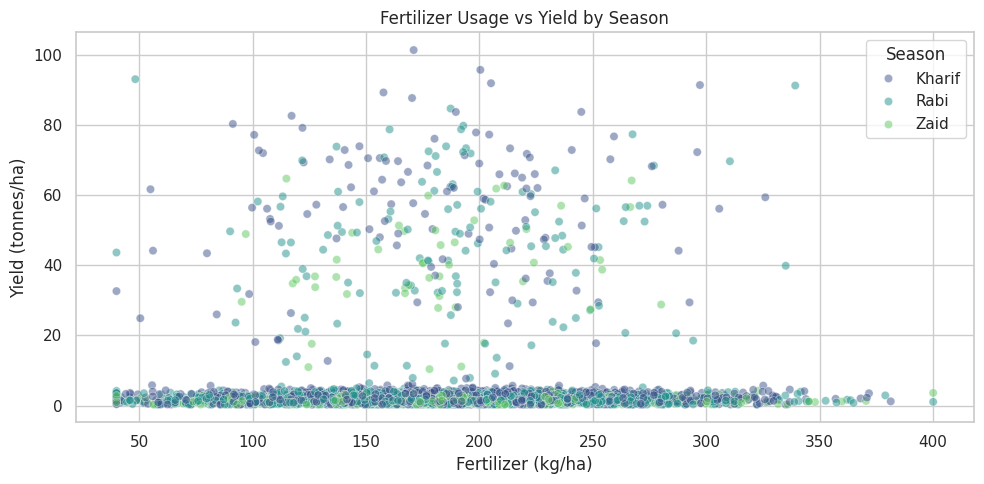

In [380]:
# Visualization 1: Fertilizer vs Yield by Season
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, palette='viridis')
plt.title('Fertilizer Usage vs Yield by Season')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (tonnes/ha)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3492/3928480952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Fertilizer_Band', y='Yield_Tonnes_Ha', palette='viridis', errorbar=None)


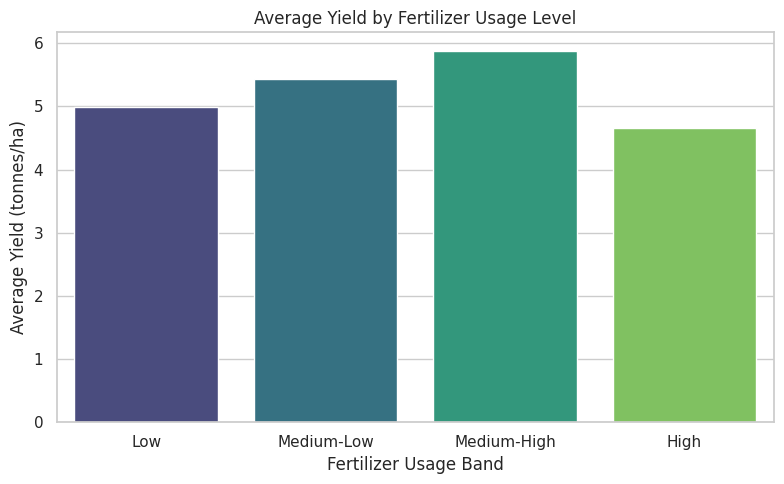

In [381]:
# Visualization 2: Yield by Fertilizer Quartile
df['Fertilizer_Band'] = pd.qcut(df['Fertilizer_kg_ha'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Fertilizer_Band', y='Yield_Tonnes_Ha', palette='viridis', errorbar=None)
plt.title('Average Yield by Fertilizer Usage Level')
plt.xlabel('Fertilizer Usage Band')
plt.ylabel('Average Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

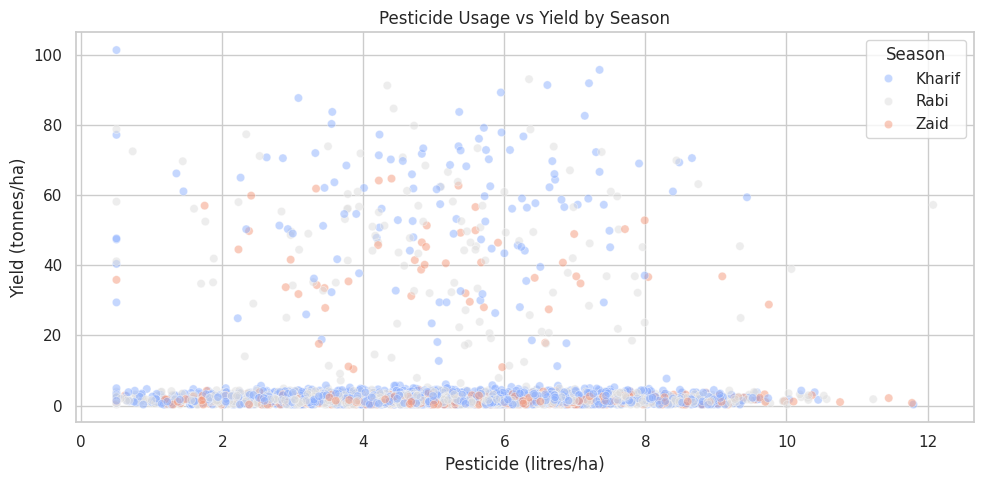

In [382]:
# Visualization 3: Pesticide vs Yield
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Pesticide_Litre_ha', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, palette='coolwarm')
plt.title('Pesticide Usage vs Yield by Season')
plt.xlabel('Pesticide (litres/ha)')
plt.ylabel('Yield (tonnes/ha)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

**Interpretation:**

The correlation between fertilizer, pesticide, seed quality and yield is almost zero in this dataset. This means there is no clear straight-line relationship between using more of these inputs and getting a better yield. Interestingly, the medium-high fertilizer group gave slightly better yield than the highest fertilizer group, which suggests that using too much fertilizer does not always help.

**Limitation:** This does not mean fertilizers and pesticides are useless. It means this dataset does not show a strong link — possibly because other factors like crop type and season are more dominant. A separate analysis for each crop type might show a different picture.

### **Key Insights**

**Insight 1:**
* Observation: Kharif season has the highest average yield (5.63 t/ha) and profit (₹1,78,914). Zaid has the lowest yield (4.64 t/ha) and even shows a negative average profit (-₹24,804).
* Evidence: Seasonal comparison table and yield boxplot across seasons.
* Interpretation: Kharif gets more rainfall (849 mm) and has higher humidity (71.8%) which seems to support better crop growth and earnings. Zaid is drier with only 305 mm rainfall which likely affects performance.
* Limitation: The crop mix is also different across seasons which could be partly responsible for these differences.

**Insight 2:**
* Observation: Sugarcane gives the highest yield in all three seasons — way above every other crop.
* Evidence: Student Analysis 1 crop and season comparison.
* Interpretation: Sugarcane is a high-biomass crop and naturally gives much higher tonnes per hectare than grain crops. It is also the most profitable crop in the dataset with an average profit of ₹8,17,187.
* Limitation: Comparing sugarcane yield directly to wheat or rice yield is not entirely fair since they are very different types of crops.

**Insight 3:**
* Observation: Wheat, Rice and Maize show negative average profits across all seasons.
* Evidence: Profit by crop and season analysis.
* Interpretation: Even though Rice is the most commonly grown crop in the dataset (690 records) and Wheat is second (614 records), both make losses on average. This suggests their production costs are too high compared to market returns.
* Limitation: These are averages. Some individual farms may still be profitable. Local cost and price conditions will vary.

**Insight 4:**
* Observation: Drip irrigation gives the highest average yield (6.58 t/ha) compared to flood (4.86), sprinkler (5.16) and rainfed (4.60).
* Evidence: Irrigation method vs yield bar chart in bivariate analysis.
* Interpretation: Drip irrigation delivers water directly to plant roots which reduces waste and supports better growth. The data shows it is the most effective irrigation method for yield.
* Limitation: Farms using drip irrigation may also differ in other ways like crop type or location which could influence yield. This is an association not a proven cause.

**Insight 5:**
* Observation: Kharif season has the highest disease and pest risk at 54.47% compared to Rabi (40.48%) and Zaid (38.22%).
* Evidence: Seasonal comparison of Disease_Pest_Risk_pct column.
* Interpretation: Higher rainfall and humidity in Kharif likely creates conditions where pests and diseases spread more easily. Even though Kharif gives the best yield, it also carries the most risk.
* Limitation: The dataset records risk as a percentage but does not tell us how much actual crop loss happened because of it.

**Insight 6:**
* Observation: NPK nutrient application is almost identical across all three seasons even though yield is clearly different.
* Evidence: Student Analysis 2 NPK comparison table and correlation heatmap.
* Interpretation: Farmers seem to apply the same amount of nutrients regardless of season. Since NPK is uniform, it cannot explain the yield differences between seasons. Other factors like rainfall and crop type matter more here.
* Limitation: Season-level averages can hide crop-specific differences. Some crops may respond differently to nutrients.

**Insight 7:**
* Observation: Punjab has the highest average yield (6.12 t/ha) among all states. Andhra Pradesh has the lowest (4.63 t/ha).
* Evidence: State-wise yield groupby analysis.
* Interpretation: Punjab is known for strong agricultural infrastructure, irrigation access and fertile soil which likely contributes to better yields. This finding is consistent with Punjab's reputation as India's agricultural heartland.
* Limitation: The dataset does not have equal representation from all states and does not capture detailed soil or infrastructure data to fully explain this difference.

**Insight 8:**
* Observation: Kharif season also has the best water efficiency — 5.89 tonnes per 1000 m³ — even though it uses more water in total (6102 m³ on average).
* Evidence: Water efficiency seasonal comparison.
* Interpretation: In Kharif, natural rainfall supports irrigation which means the crops produce more output per unit of water used. Zaid, being dry, has the worst water efficiency at 4.41 t per 1000 m³.
* Limitation: Water efficiency here benefits from natural rainfall. It does not mean Kharif farmers are necessarily managing water better — rainfall is giving them a natural advantage.

### **Recommendations**

Based only on the evidence found in the dataset, provide practical and data-driven recommendations.

Recommendations should:
* Clearly connect to an observed finding.
* Avoid unsupported assumptions.
* Acknowledge important limitations.
* Focus on what the data can reasonably support.

1. Focus on high-value crops in Kharif season.

Kharif shows the best yield and profit in the dataset. Crops like Sugarcane and Chilli which are profitable across all seasons could be prioritized during Kharif when conditions are most favorable.

Limitation: Water availability and local soil conditions should be checked before making crop choices.

2. Look into why Wheat, Rice and Maize are making losses.

These are the most grown crops in the dataset but they show negative average profits. It would be worth investigating whether their input costs can be reduced or whether they need better market price support.

Limitation: These are dataset averages. Individual farm situations will differ.

3. Encourage drip irrigation.

Drip irrigation is linked to the highest average yield in this dataset. Making drip irrigation more accessible to farmers — especially in lower-yield regions — could help improve overall agricultural performance.

Limitation: Drip irrigation has a higher setup cost and may not suit all crops equally. Suitability should be assessed before recommending it widely.

4. Address pest and disease risk in Kharif.

Even though Kharif gives the best results, it also has the highest pest and disease risk (54.47%). Targeted pest management during this season could help protect yields.

Limitation: The dataset shows risk percentage but not actual losses, so the true impact cannot be measured from this data alone.

5. Consider crop-specific nutrient plans.

The data shows that NPK application is the same across all seasons and crops. Adjusting nutrient application based on which crop is being grown and which season it is may improve efficiency and reduce unnecessary costs.

Limitation: This would need input from agricultural experts and cannot be decided from this dataset alone.

### **Conclusion**

This project analyzed 4000 farm records across 28 variables to understand how agricultural performance varies across Kharif, Rabi and Zaid seasons.

Kharif emerged as the strongest season with the highest yield and profit, supported by better rainfall and humidity. Zaid was the weakest with negative average profits for most crops. Sugarcane and Chilli were the most profitable crops while Wheat, Rice and Maize showed negative average profits despite being the most commonly grown. Drip irrigation was associated with the best yield outcomes.

Importantly, farming inputs like NPK, fertilizer and pesticide showed almost no correlation with yield, suggesting that seasonal conditions and crop type are stronger drivers of performance in this dataset.

The findings are associational and not causal. Future work could explore prediction models or deeper state and crop level analysis.

### **Project Checklist**

Before submission, confirm that your notebook includes:

* Dataset loaded successfully
* Top 5 rows analyzed
* Dataset shape and structure examined
* Data types examined
* Missing values identified and handled
* Duplicate records identified and handled
* Descriptive/statistical analysis performed
* Outliers investigated
* Univariate analysis completed
* Bivariate analysis completed
* Multivariate analysis completed
* Correlation analysis completed
* Seasonal comparisons performed
* At least 3 student-designed analyses completed
* At least 8 meaningful insights documented
* Evidence-based recommendations provided
* Limitations discussed
* Final conclusion provided